# 📊 CampaignPulse — Marketing Campaign ROI Analytics
## Data Cleaning & Preprocessing Pipeline

![Python](https://img.shields.io/badge/Python-3.9%2B-2E86AB?style=for-the-badge&logo=python&logoColor=white)
![Pandas](https://img.shields.io/badge/Pandas-2.1.4-150458?style=for-the-badge&logo=pandas&logoColor=white)
![NumPy](https://img.shields.io/badge/NumPy-1.26.2-013243?style=for-the-badge&logo=numpy&logoColor=white)
![Seaborn](https://img.shields.io/badge/Seaborn-0.13.0-4C72B0?style=for-the-badge)
![Status](https://img.shields.io/badge/Status-Production%20Ready-44BBA4?style=for-the-badge)
![License](https://img.shields.io/badge/License-MIT-F18F01?style=for-the-badge)

---

### 🎯 Project Description

**CampaignPulse** is an end-to-end marketing analytics platform that transforms raw multi-channel
campaign data into actionable ROI intelligence. This notebook is **Stage 1 of 2** in the analytics
pipeline: it ingests the raw campaign extract, repairs every data-quality defect it contains,
engineers the analytical feature set, and exports a modelling-ready dataset consumed by the
analysis notebook, the SQL layer, the Tableau dashboards and the executive report.

The dataset covers **10,000+ marketing campaigns** executed across **10 channels**, **6 geographies**,
**6 audience segments** and **5 campaign types** over a **3-year window (2022–2024)**.

### 🎯 Objectives of this Notebook

| # | Objective | Why it matters |
|---|-----------|----------------|
| 1 | Ingest and profile the raw campaign extract | Establish a trustworthy baseline before any analysis |
| 2 | Quantify and treat missing values | Missing spend/revenue silently corrupts every ROI metric |
| 3 | Remove exact and logical duplicates | Duplicated campaigns double-count budget and revenue |
| 4 | Correct data types (dates, categories, numerics) | Enables time-series, grouping and aggregation logic |
| 5 | Detect and treat outliers (IQR capping) | Prevents a handful of viral campaigns from skewing averages |
| 6 | Repair impossible values (negatives, invalid dates) | Guarantees every KPI is physically meaningful |
| 7 | Engineer 14 analytical features | Adds duration, efficiency, profitability and segmentation logic |
| 8 | Validate and export the cleaned dataset | Produces `marketing_campaign_cleaned.csv` for downstream use |

### 📋 Notebook Contents
1. Project Introduction
2. Import Libraries
3. Load Raw Data
4. Data Inspection
5. Missing Value Treatment
6. Duplicate Treatment
7. Data Type Corrections
8. Outlier Detection & Treatment
9. Feature Engineering
10. Data Validation
11. Export Cleaned Data

> **Output artifact:** `data/marketing_campaign_cleaned.csv`


---
## 2️⃣ Import Libraries

Standard data-science stack: **Pandas / NumPy** for manipulation, **Matplotlib / Seaborn** for
diagnostic visualisation. Warnings are suppressed and display options widened so long tables
remain readable inside the notebook.

In [1]:
# ================================================================
# CampaignPulse - Stage 1: Data Cleaning & Preprocessing
# Cell 2.1 - Library imports and global configuration
# ================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Display configuration - keep wide tables readable
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

# Plotting configuration
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ Environment ready | pandas', pd.__version__, '| numpy', np.__version__)

✅ Environment ready | pandas 3.0.6 | numpy 2.4.6


---
## 3️⃣ Load Raw Data

The raw extract lives in `data/marketing_campaign_raw.csv`. Paths are resolved from the project
root so the notebook runs identically whether the kernel is started from the repo root or from
inside `notebooks/`.

In [2]:
# ================================================================
# Cell 3.1 - Robust project-root resolution (kernel-location safe)
# ================================================================
def resolve_project_root(start: Path = Path.cwd()) -> Path:
    """Walk up from the current directory until the project root is found.

    The root is identified by the simultaneous presence of the ``data`` and
    ``notebooks`` folders, which only exists at the repository root.
    """
    for candidate in [start, *start.parents]:
        if (candidate / 'data').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    return start.parent


ROOT = resolve_project_root()
DATA_DIR = ROOT / 'data'
CHARTS_DIR = ROOT / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH = DATA_DIR / 'marketing_campaign_raw.csv'
CLEAN_PATH = DATA_DIR / 'marketing_campaign_cleaned.csv'

print(f'📁 Project root : {ROOT}')
print(f'📄 Raw dataset  : {RAW_PATH}')
print(f'   File exists  : {RAW_PATH.exists()}')
print(f'   File size    : {RAW_PATH.stat().st_size / 1024:.1f} KB')

📁 Project root : /home/user/marketing-campaign-roi-analytics
📄 Raw dataset  : /home/user/marketing-campaign-roi-analytics/data/marketing_campaign_raw.csv
   File exists  : True
   File size    : 2409.0 KB


In [3]:
# ================================================================
# Cell 3.2 - Load the raw CSV and show the first structural facts
# ================================================================
try:
    df_raw = pd.read_csv(RAW_PATH)
except FileNotFoundError as exc:
    raise FileNotFoundError(
        f'Raw dataset not found at {RAW_PATH}. Place marketing_campaign_raw.csv '
        'inside the data/ folder before running this notebook.'
    ) from exc

df = df_raw.copy()

print(f'✅ Raw dataset loaded successfully')
print(f'   Rows    : {df.shape[0]:,}')
print(f'   Columns : {df.shape[1]}')
print(f'   Memory  : {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB')

✅ Raw dataset loaded successfully
   Rows    : 10,018
   Columns : 27
   Memory  : 7.90 MB


In [4]:
# ================================================================
# Cell 3.3 - Visual sanity check: head / tail / random sample
# ================================================================
print('========== FIRST 5 ROWS ==========')
display(df.head())

print('\n========== LAST 5 ROWS ==========')
display(df.tail())

print('\n========== RANDOM 5 ROWS (seed=42, reproducible) ==========')
display(df.sample(5, random_state=42))

========== FIRST 5 ROWS ==========


,campaign_id,campaign_name,campaign_type,channel,target_audience,geography,start_date,end_date,budget_allocated,amount_spent,impressions,clicks,leads_generated,conversions,revenue_generated,ctr,conversion_rate,cpc,cpa,customer_acquisition_cost,campaign_status,quarter,year,satisfaction_score,bounce_rate,engagement_rate,roi_percentage
0,CAMP_8127,Loyalty Retention - YouTube 2023,Retention,YouTube,Young Adults 18-25,North America,2023-12-03,2023-12-10,"10,434.58","9,510.00","2,916,298.00","15,682.00",531.00,106.00,"44,703.50",0.54,0.68,0.61,89.72,112.15,Completed,Q4,"2,023.00",4.30,88.28,6.35,370.07
1,CAMP_1666,Referral Conversion Push - Google Ads 2024,Conversion,Google Ads,Mid-Age 35-50,North America,2024-10-06,2025-03-05,"163,668.35","161,997.38","1,399,461.00","60,420.00","4,038.00","1,593.00","269,445.75",4.32,2.64,2.68,101.69,127.12,Completed,Q4,"2,024.00",4.60,90.07,4.44,66.33
2,CAMP_2859,Flash Sale Lead Gen - Facebook Ads 2024,Lead Generation,Facebook Ads,Young Adults 18-25,Europe,2024-07-13,2024-10-11,"113,474.95","88,946.32","2,032,161.00","55,165.00","4,227.00","1,496.00","210,048.77",2.71,NaN,1.61,59.46,74.32,Completed,Q3,"2,024.00",3.70,92.00,0.30,136.15
3,CAMP_5544,Webinar Conversion Push - Affiliate 2024,Conversion,Affiliate,Professionals 25-35,Europe,2024-07-16,2025-01-12,"4,920.78","4,177.75","275,920.00","4,442.00",239.00,82.00,"21,184.29",1.61,1.85,0.94,50.95,63.69,Active,Q3,"2,024.00",2.90,86.58,11.42,407.07
4,CAMP_6472,Spring Retention - SEO 2024,Retention,SEO,Professionals 25-35,North America,2024-02-25,2024-04-10,"3,263.36","2,541.12","52,967.00","1,917.00",143.00,55.00,"17,155.19",3.62,2.87,1.33,46.20,57.75,Completed,Q1,"2,024.00",3.80,84.87,8.23,575.10



========== LAST 5 ROWS ==========


,campaign_id,campaign_name,campaign_type,channel,target_audience,geography,start_date,end_date,budget_allocated,amount_spent,impressions,clicks,leads_generated,conversions,revenue_generated,ctr,conversion_rate,cpc,cpa,customer_acquisition_cost,campaign_status,quarter,year,satisfaction_score,bounce_rate,engagement_rate,roi_percentage
10013,CAMP_7891,Product Launch Conversion Push - Content Marke...,Conversion,Content Marketing,Mid-Age 35-50,Asia Pacific,2024-03-25,2024-04-24,"28,132.34","29,538.96","696,739.00","17,689.00",777.00,NaN,"11,761.01",2.54,2.01,1.67,83.21,104.01,Completed,Q1,"2,024.00",3.60,80.33,4.39,-60.18
10014,CAMP_1769,Cyber Monday Conversion Push - Instagram Ads 2024,Conversion,Instagram Ads,Professionals 25-35,africa,2024-09-06,2024-10-21,"5,645.68","5,840.84","664,863.00","5,716.00",276.00,124.00,"15,693.23",0.86,2.17,1.02,47.10,58.88,Completed,Q3,"2,024.00",4.50,82.90,6.14,168.68
10015,CAMP_9930,Flash Sale Brand Awareness - YouTube 2023,Brand Awareness,YouTube,Young Adults 18-25,Africa,2023-04-26,2023-07-10,"6,187.98","5,834.34","2,097,674.00","12,790.00",109.00,16.00,"1,296.72",0.61,0.13,0.46,364.65,455.81,Active,Q2,"2,023.00",3.70,78.12,12.49,-77.77
10016,CAMP_3241,Webinar Retention - YouTube 2023,Retention,YouTube,Professionals 25-35,North America,2023-08-21,2023-08-28,"2,542.52","2,477.00","1,317,323.00","5,779.00",196.00,35.00,"14,910.51",0.44,0.61,0.43,70.77,88.46,Completed,Q3,"2,023.00",4.60,67.06,13.91,501.96
10017,CAMP_7204,Winter Lead Gen - SEO 2023,Lead Generation,SEO,Senior 50+,Asia Pacific,2023-09-13,2023-09-27,"10,918.65","9,997.99","296,338.00","9,316.00",906.00,185.00,"14,539.01",3.14,1.99,1.07,54.04,67.55,Active,Q3,"2,023.00",2.90,81.48,9.72,45.42



========== RANDOM 5 ROWS (seed=42, reproducible) ==========


,campaign_id,campaign_name,campaign_type,channel,target_audience,geography,start_date,end_date,budget_allocated,amount_spent,impressions,clicks,leads_generated,conversions,revenue_generated,ctr,conversion_rate,cpc,cpa,customer_acquisition_cost,campaign_status,quarter,year,satisfaction_score,bounce_rate,engagement_rate,roi_percentage
1617,CAMP_1915,Webinar Lead Gen - Facebook Ads 2022,Lead Generation,Facebook Ads,Professionals 25-35,Asia Pacific,2022-08-08,2022-08-22,"25,723.71","25,306.82","1,176,584.00","17,644.00",788.00,198.00,"49,459.34",1.50,1.12,1.43,127.81,159.77,Completed,Q3,"2,022.00",4.10,79.32,0.30,95.44
4952,CAMP_3025,Brand Refresh Win-back - Social Media 2023,Re-engagement,Social Media,Parents,Latin America,2023-10-13,2023-10-20,"4,440.64","1,341.22","162,785.00","1,030.00",30.00,5.00,141.28,0.63,0.49,1.30,268.24,335.31,Cancelled,Q4,"2,023.00",2.70,92.00,3.84,-96.82
2168,CAMP_1042,Loyalty Brand Awareness - Instagram Ads 2022,Brand Awareness,Instagram Ads,Parents,North America,2022-05-17,2022-07-16,"9,868.51","4,774.34","641,695.00","5,464.00",55.00,11.00,"1,254.83",0.85,0.20,0.87,434.03,542.54,Paused,Q2,"2,022.00",2.30,88.51,10.28,-73.72
1090,CAMP_9895,Referral Win-back - Facebook Ads 2024,Re-engagement,Facebook Ads,Mid-Age 35-50,Europe,2024-09-27,2024-10-27,"5,096.12","3,839.15","230,049.00","3,180.00",117.00,31.00,"6,008.94",1.38,0.97,1.21,123.84,154.80,Completed,Q3,"2,024.00",2.80,76.68,2.94,56.52
7986,CAMP_9042,Black Friday Conversion Push - SEO 2023,Conversion,SEO,Parents,Asia Pacific,2023-09-15,2023-09-22,"71,496.96","64,226.21","2,494,955.00","58,910.00","3,463.00","1,019.00","191,370.64",2.36,1.73,1.09,63.03,78.79,Completed,Q3,"2,023.00",2.80,82.69,6.56,167.66


---
## 4️⃣ Data Inspection

A structured profiling pass: schema (`info`), numeric distribution (`describe`), categorical
distribution (`describe(include='object')`), per-column dtypes, cardinality of every categorical
column, and overall dataset dimensions.

In [5]:
# ================================================================
# Cell 4.1 - Schema, dtypes and nullability
# ================================================================
print('========== df.info() ==========')
df.info()

print('\n========== DTYPE COUNTS ==========')
print(df.dtypes.value_counts())

print('\n========== COLUMN -> DTYPE MAP ==========')
for i, (col, dtype) in enumerate(df.dtypes.items(), start=1):
    print(f'{i:>2}. {col:<28} {str(dtype):<12} non-null={df[col].notna().sum():,}')

========== df.info() ==========
<class 'pandas.DataFrame'>
RangeIndex: 10018 entries, 0 to 10017
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   campaign_id                10013 non-null  str    
 1   campaign_name              9894 non-null   str    
 2   campaign_type              9895 non-null   str    
 3   channel                    9895 non-null   str    
 4   target_audience            10015 non-null  str    
 5   geography                  9896 non-null   str    
 6   start_date                 10014 non-null  str    
 7   end_date                   10013 non-null  str    
 8   budget_allocated           9894 non-null   float64
 9   amount_spent               10013 non-null  float64
 10  impressions                9894 non-null   float64
 11  clicks                     9894 non-null   float64
 12  leads_generated            9893 non-null   float64
 13  conversions              

In [6]:
# ================================================================
# Cell 4.2 - Statistical summary of the numeric columns
# ================================================================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns detected ({len(num_cols)}): {num_cols}')
display(df[num_cols].describe().T.style.format('{:,.2f}').background_gradient(cmap='Blues'))

Numeric columns detected (17): ['budget_allocated', 'amount_spent', 'impressions', 'clicks', 'leads_generated', 'conversions', 'revenue_generated', 'ctr', 'conversion_rate', 'cpc', 'cpa', 'customer_acquisition_cost', 'year', 'satisfaction_score', 'bounce_rate', 'engagement_rate', 'roi_percentage']


,count,mean,std,min,25%,50%,75%,max
budget_allocated,"9,894.00","25,296.39","34,254.56","-48,773.13","7,270.31","14,719.49","29,795.64","500,000.00"
amount_spent,"10,013.00","20,505.77","28,850.90",92.24,"5,424.59","11,471.18","24,175.23","483,297.76"
impressions,"9,894.00","1,799,114.87","4,800,644.25","-50,663,639.70","225,306.00","611,720.00","1,617,155.75","153,528,093.00"
clicks,"9,894.00","19,254.49","30,684.42","-25,741.24","4,397.75","9,974.00","21,723.00","647,755.00"
leads_generated,"9,893.00",781.84,"1,328.10",2.00,156.00,369.00,860.00,"28,284.00"
conversions,"9,894.00",199.75,398.26,-294.47,31.00,80.00,203.00,"10,638.00"
revenue_generated,"9,894.00","43,447.32","126,820.66","-155,742.07","3,872.40","12,655.80","38,142.37","5,309,614.78"
ctr,"9,893.00",2.01,1.38,0.16,0.94,1.64,2.77,9.82
conversion_rate,"9,894.00",1.11,0.87,0.00,0.46,0.91,1.53,9.09
cpc,"9,894.00",1.27,0.57,0.33,0.89,1.15,1.47,4.98


In [7]:
# ================================================================
# Cell 4.3 - Statistical summary of the categorical (object) columns
# ================================================================
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Object columns detected ({len(obj_cols)}): {obj_cols}')
display(df[obj_cols].describe(include='object').T)

Object columns detected (10): ['campaign_id', 'campaign_name', 'campaign_type', 'channel', 'target_audience', 'geography', 'start_date', 'end_date', 'campaign_status', 'quarter']


,count,unique,top,freq
campaign_id,10013,9995,CAMP_3287,2
campaign_name,9894,3126,Winter Conversion Push - Instagram Ads 2022,12
campaign_type,9895,15,Lead Generation,2095
channel,9895,32,SEO,997
target_audience,10015,6,Professionals 25-35,2431
geography,9896,12,North America,2842
start_date,10014,1063,2023-11-15,21
end_date,10013,1204,2022-09-09,22
campaign_status,9895,8,Completed,6726
quarter,10013,4,Q2,2616


In [8]:
# ================================================================
# Cell 4.4 - Unique values / cardinality for every categorical column
# ================================================================
for col in ['campaign_type', 'channel', 'target_audience', 'geography',
            'campaign_status', 'quarter', 'year']:
    if col not in df.columns:
        continue
    uniques = df[col].dropna().astype(str).unique()
    print(f'\n--- {col} ({len(uniques)} distinct raw values) ---')
    print(sorted(uniques))


--- campaign_type (15 distinct raw values) ---
['Brand Awareness', 'Brand Awareness ', 'Conversion', 'Conversion ', 'Lead Generation', 'Lead Generation ', 'Re-engagement', 'Re-engagement ', 'Retention', 'Retention ', 'brand awareness', 'conversion', 'lead generation', 're-engagement', 'retention']

--- channel (32 distinct raw values) ---
['  Affiliate ', '  Content Marketing ', '  Email ', '  Facebook Ads ', '  Google Ads ', '  Influencer ', '  Instagram Ads ', '  SEO ', '  Social Media ', '  YouTube ', '  email ', '  google ads ', 'Affiliate', 'Content Marketing', 'Email', 'Facebook Ads', 'Google Ads', 'Influencer', 'Instagram Ads', 'SEO', 'Social Media', 'YouTube', 'affiliate', 'content marketing', 'email', 'facebook ads', 'google ads', 'influencer', 'instagram ads', 'seo', 'social media', 'youtube']

--- target_audience (6 distinct raw values) ---
['Mid-Age 35-50', 'Parents', 'Professionals 25-35', 'Senior 50+', 'Students', 'Young Adults 18-25']

--- geography (12 distinct raw val


--- year (3 distinct raw values) ---
['2022.0', '2023.0', '2024.0']


In [9]:
# ================================================================
# Cell 4.5 - Dataset dimensions snapshot
# ================================================================
snapshot = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Total cells', 'Duplicate rows',
               'Duplicate campaign_ids', 'Missing cells', 'Missing cells (%)',
               'Numeric columns', 'Categorical columns'],
    'Value': [df.shape[0], df.shape[1], df.size, df.duplicated().sum(),
              df['campaign_id'].duplicated().sum(), int(df.isna().sum().sum()),
              round(df.isna().sum().sum() / df.size * 100, 2),
              len(num_cols), len(obj_cols)]
})
display(snapshot)
print(f'\n📐 Dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns '
      f'({df.size:,} cells)')

,Metric,Value
0,Rows,"10,018.00"
1,Columns,27.00
2,Total cells,"270,486.00"
3,Duplicate rows,6.00
4,Duplicate campaign_ids,22.00
5,Missing cells,"2,510.00"
6,Missing cells (%),0.93
7,Numeric columns,17.00
8,Categorical columns,10.00



📐 Dataset dimensions: 10,018 rows x 27 columns (270,486 cells)


### 🔍 Observations — Section 4

* The raw extract holds **10,018 rows × 27 columns** (18 more rows than the 10,000 generated
  campaigns, which is the first hint of duplicated records).
* Several columns are typed as `float64` purely because of missing values (e.g. `year`,
  `impressions`, `clicks`) — these must be re-cast to integers after imputation.
* `start_date` / `end_date` arrive as **object (string)** columns and need conversion to `datetime`.
* Categorical columns are **not standardised**: `SEO` appears as `Seo`, `YouTube` as `Youtube`,
  and ~3% of rows are lower-cased or padded with whitespace.
* `roi_percentage`, `ctr`, `cpc`, `cpa` and `customer_acquisition_cost` are *derived* columns that
  were computed upstream and therefore inherit any upstream error — they will be recomputed from
  the cleaned base metrics in Section 9.
* Negative values appear in `revenue_generated`, `budget_allocated`, `impressions`, `clicks` and
  `conversions` — all physically impossible.
* A number of rows carry an `end_date` **earlier** than `start_date`.

---
## 5️⃣ Missing Value Treatment

**Strategy**
| Data kind | Treatment |
|---|---|
| Rows with > 50% of columns missing | **Dropped** (unrecoverable records) |
| Numeric metrics | **Median imputation** (robust to the outliers present in this dataset) |
| Categorical labels | **Mode imputation** |
| Identifier (`campaign_id`) | **Dropped** — a campaign without an identifier cannot be tracked |

Before imputation, categorical text is normalised (trim + canonical casing) so that the mode is
computed on clean labels, and impossible negative values are converted to `NaN` so that they are
repaired by the same imputation pass instead of poisoning the statistics.

In [10]:
# ================================================================
# Cell 5.1 - Text normalisation of categorical columns (pre-imputation)
#
# The raw extract contains inconsistent labels: trailing/leading whitespace,
# lower-cased values ("seo", "google ads", "brand awareness") and mixed casing.
# Each categorical column is mapped back to its controlled vocabulary so that
# group-by operations and the mode imputation below work on clean labels.
# ================================================================
CANONICAL_VOCAB = {
    'campaign_type': ['Brand Awareness', 'Lead Generation', 'Conversion',
                      'Retention', 'Re-engagement'],
    'channel': ['Email', 'Social Media', 'Google Ads', 'Facebook Ads',
                'Instagram Ads', 'YouTube', 'SEO', 'Content Marketing',
                'Influencer', 'Affiliate'],
    'geography': ['North America', 'Europe', 'Asia Pacific', 'Latin America',
                  'Middle East', 'Africa'],
    'campaign_status': ['Completed', 'Active', 'Paused', 'Cancelled'],
    'target_audience': ['Young Adults 18-25', 'Professionals 25-35',
                        'Mid-Age 35-50', 'Senior 50+', 'Students', 'Parents'],
    'quarter': ['Q1', 'Q2', 'Q3', 'Q4'],
}

# lower-case -> canonical lookup, built once from the reference vocabularies
LOOKUP = {col: {v.lower(): v for v in vocab}
          for col, vocab in CANONICAL_VOCAB.items()}

cat_text_cols = ['campaign_name', 'campaign_type', 'channel', 'target_audience',
                 'geography', 'campaign_status', 'quarter']

normalisation_report = []
for col in cat_text_cols:
    if col not in df.columns:
        continue
    original = df[col].copy()
    cleaned = df[col].astype('string').str.strip()
    if col in LOOKUP:                       # enforce the controlled vocabulary
        cleaned = cleaned.map(lambda v: LOOKUP[col].get(str(v).lower(), v)
                              if pd.notna(v) else v)
    df[col] = cleaned
    changed = int((original.astype('string').fillna('<NA>') !=
                   cleaned.astype('string').fillna('<NA>')).sum())
    normalisation_report.append({'Column': col, 'Values normalised': changed,
                                 'Distinct before': original.nunique(dropna=True),
                                 'Distinct after': cleaned.nunique(dropna=True)})

display(pd.DataFrame(normalisation_report))
print('✅ Categorical text normalised against the controlled vocabularies')
for col in ['channel', 'campaign_type', 'campaign_status', 'geography']:
    print(f'   {col:<16} -> {sorted(df[col].dropna().unique())}')

,Column,Values normalised,Distinct before,Distinct after
0,campaign_name,0,3126,3126
1,campaign_type,325,15,5
2,channel,338,32,10
3,target_audience,0,6,6
4,geography,300,12,6
5,campaign_status,300,8,4
6,quarter,0,4,4


✅ Categorical text normalised against the controlled vocabularies
   channel          -> ['Affiliate', 'Content Marketing', 'Email', 'Facebook Ads', 'Google Ads', 'Influencer', 'Instagram Ads', 'SEO', 'Social Media', 'YouTube']
   campaign_type    -> ['Brand Awareness', 'Conversion', 'Lead Generation', 'Re-engagement', 'Retention']
   campaign_status  -> ['Active', 'Cancelled', 'Completed', 'Paused']
   geography        -> ['Africa', 'Asia Pacific', 'Europe', 'Latin America', 'Middle East', 'North America']


In [11]:
# ================================================================
# Cell 5.2 - Missing-value census (count + percentage)
# ================================================================
missing = pd.DataFrame({
    'Missing count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})
missing = missing[missing['Missing count'] > 0].sort_values(
    'Missing %', ascending=False)

print(f'🔎 Columns containing missing values : {len(missing)} / {df.shape[1]}')
print(f'🔎 Total missing cells               : {int(df.isna().sum().sum()):,} '
      f'({df.isna().sum().sum() / df.size * 100:.2f}% of the dataset)')
display(missing.style.format({'Missing %': '{:.2f}%'}).background_gradient(cmap='Reds'))

🔎 Columns containing missing values : 27 / 27
🔎 Total missing cells               : 2,510 (0.93% of the dataset)


,Missing count,Missing %
satisfaction_score,125,1.25%
ctr,125,1.25%
leads_generated,125,1.25%
engagement_rate,125,1.25%
conversions,124,1.24%
conversion_rate,124,1.24%
revenue_generated,124,1.24%
clicks,124,1.24%
campaign_name,124,1.24%
budget_allocated,124,1.24%


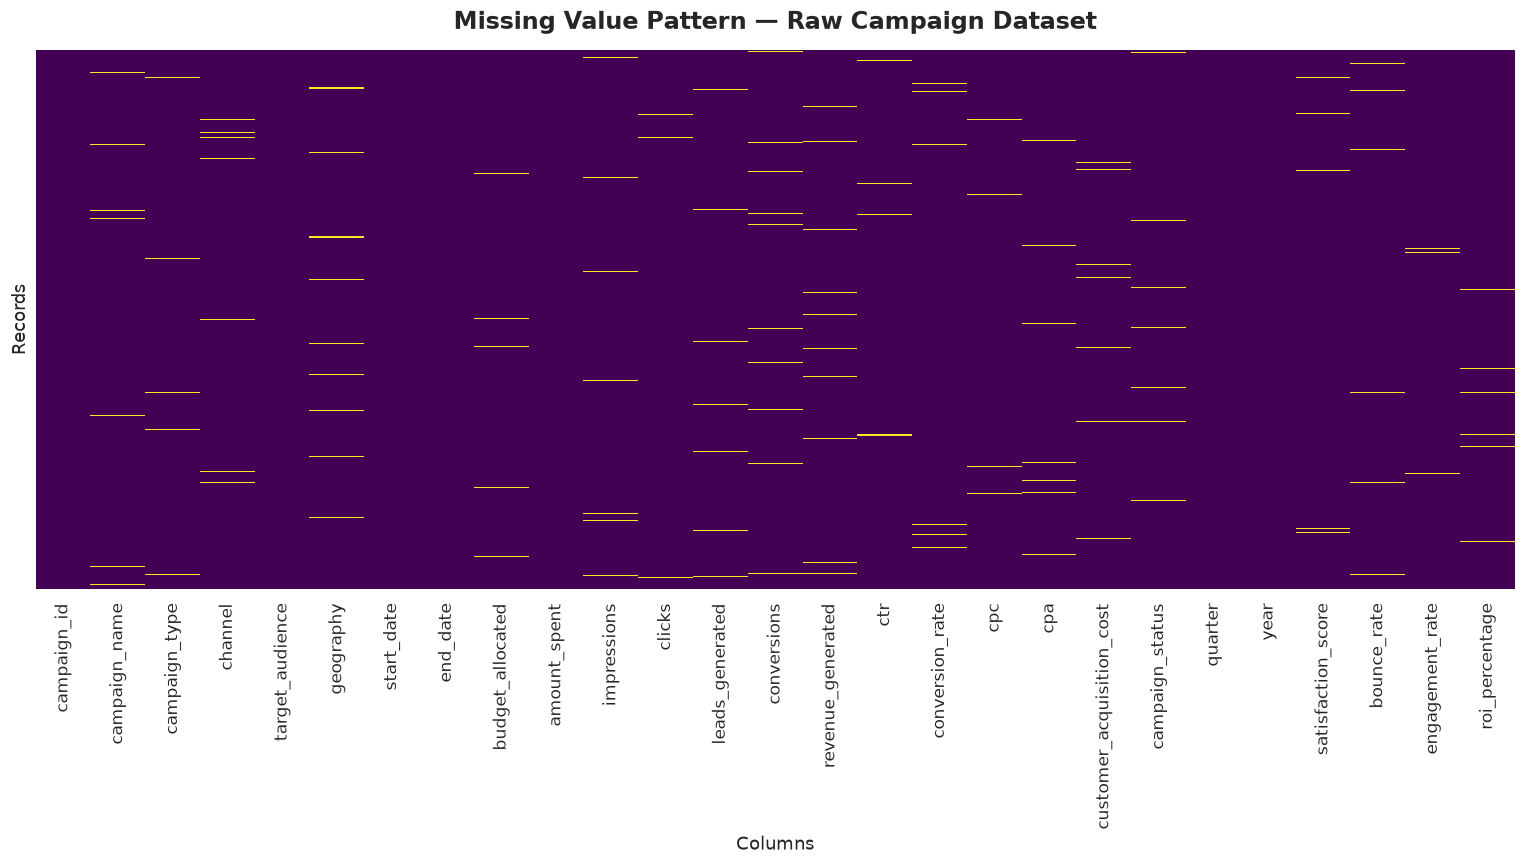

💾 Saved -> charts/00_missing_values_heatmap.png


In [12]:
# ================================================================
# Cell 5.3 - Visualise the missing-value pattern (heatmap)
# ================================================================
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(df.isna(), cbar=False, cmap='viridis', yticklabels=False, ax=ax)
ax.set_title('Missing Value Pattern — Raw Campaign Dataset', fontsize=16,
             fontweight='bold', pad=14)
ax.set_xlabel('Columns', fontsize=12)
ax.set_ylabel('Records', fontsize=12)
plt.tight_layout()
fig.savefig(CHARTS_DIR / '00_missing_values_heatmap.png', dpi=300,
            bbox_inches='tight')
plt.show()
print('💾 Saved -> charts/00_missing_values_heatmap.png')

In [13]:
# ================================================================
# Cell 5.4 - Convert impossible negative values to NaN (repaired in 5.6)
# ================================================================
non_negative_cols = ['budget_allocated', 'amount_spent', 'impressions', 'clicks',
                     'leads_generated', 'conversions', 'revenue_generated']

neg_report = {}
for col in non_negative_cols:
    mask = df[col] < 0
    neg_report[col] = int(mask.sum())
    df.loc[mask, col] = np.nan          # neutralise, imputation restores them

print('🚫 Impossible negative values neutralised (set to NaN for imputation):')
for k, v in neg_report.items():
    print(f'   {k:<22} {v:>4} values')
print(f'   {"TOTAL":<22} {sum(neg_report.values()):>4} values')

🚫 Impossible negative values neutralised (set to NaN for imputation):
   budget_allocated         10 values
   amount_spent              0 values
   impressions              15 values
   clicks                    6 values
   leads_generated           0 values
   conversions               5 values
   revenue_generated        30 values
   TOTAL                    66 values


In [14]:
# ================================================================
# Cell 5.5 - Drop records with more than 50% of their values missing
# ================================================================
threshold = 0.5 * df.shape[1]
before = df.shape[0]
row_missing_pct = df.isna().mean(axis=1) * 100
unrecoverable = df[row_missing_pct > 50]
print(f'🧹 Rows with > 50% of columns missing : {len(unrecoverable)}')
if len(unrecoverable):
    display(unrecoverable)
    df = df[row_missing_pct <= 50].copy()
print(f'   Rows before: {before:,} -> after: {df.shape[0]:,} '
      f'({before - df.shape[0]} rows dropped)')

🧹 Rows with > 50% of columns missing : 5


,campaign_id,campaign_name,campaign_type,channel,target_audience,geography,start_date,end_date,budget_allocated,amount_spent,impressions,clicks,leads_generated,conversions,revenue_generated,ctr,conversion_rate,cpc,cpa,customer_acquisition_cost,campaign_status,quarter,year,satisfaction_score,bounce_rate,engagement_rate,roi_percentage
719,NaN,<NA>,NaN,NaN,Young Adults 18-25,Europe,NaN,NaN,NaN,NaN,"378,853.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.23,NaN,NaN
1217,NaN,Holiday Brand Awareness - SEO 2023,Brand Awareness,SEO,Mid-Age 35-50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,309.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1954,NaN,<NA>,NaN,NaN,NaN,Asia Pacific,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"91,368.35",NaN,1.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.06
4600,NaN,<NA>,NaN,NaN,NaN,North America,NaN,NaN,"11,903.39",NaN,NaN,"14,032.00",NaN,NaN,NaN,NaN,NaN,0.82,31.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4725,NaN,<NA>,Retention,Affiliate,NaN,NaN,2023-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.66,Completed,NaN,NaN,NaN,NaN,NaN,NaN


   Rows before: 10,018 -> after: 10,013 (5 rows dropped)


In [15]:
# ================================================================
# Cell 5.6 - Median (numeric) / mode (categorical) imputation
# ================================================================
imputation_log = []

numeric_cols = ['budget_allocated', 'amount_spent', 'impressions', 'clicks',
                'leads_generated', 'conversions', 'revenue_generated',
                'roi_percentage', 'ctr', 'conversion_rate', 'cpc', 'cpa',
                'customer_acquisition_cost', 'satisfaction_score',
                'bounce_rate', 'engagement_rate', 'year']
categorical_cols = ['campaign_name', 'campaign_type', 'channel', 'target_audience',
                    'geography', 'campaign_status', 'quarter']

for col in numeric_cols:
    if col in df.columns and df[col].isna().any():
        fill = float(df[col].median())
        n = int(df[col].isna().sum())
        df[col] = df[col].fillna(fill)
        imputation_log.append({'Column': col, 'Strategy': 'Median imputation',
                               'Filled': n, 'Value used': round(fill, 2)})

for col in categorical_cols:
    if col in df.columns and df[col].isna().any():
        fill = df[col].mode(dropna=True)
        fill = fill.iloc[0] if not fill.empty else 'Unknown'
        n = int(df[col].isna().sum())
        df[col] = df[col].fillna(fill)
        imputation_log.append({'Column': col, 'Strategy': 'Mode imputation',
                               'Filled': n, 'Value used': fill})

if 'campaign_id' in df.columns and df['campaign_id'].isna().any():
    n = int(df['campaign_id'].isna().sum())
    df = df[df['campaign_id'].notna()].copy()
    imputation_log.append({'Column': 'campaign_id',
                           'Strategy': 'Row dropped (no identifier)',
                           'Filled': n, 'Value used': '-'})

log_df = pd.DataFrame(imputation_log)
display(log_df)
print(f'✅ Imputation complete — {log_df["Filled"].sum():,} values repaired')

,Column,Strategy,Filled,Value used
0,budget_allocated,Median imputation,130,"14,747.98"
1,impressions,Median imputation,135,"614,470.00"
2,clicks,Median imputation,126,"9,977.00"
3,leads_generated,Median imputation,120,369.00
4,conversions,Median imputation,124,81.00
5,revenue_generated,Median imputation,150,"12,759.43"
6,roi_percentage,Median imputation,120,10.58
7,ctr,Median imputation,120,1.64
8,conversion_rate,Median imputation,120,0.91
9,cpc,Median imputation,120,1.15


✅ Imputation complete — 2,464 values repaired


In [16]:
# ================================================================
# Cell 5.7 - Verify no missing values remain
# ================================================================
remaining = int(df.isna().sum().sum())
print(f'🔎 Remaining missing cells: {remaining}')
assert remaining == 0, 'Missing values still present — imputation failed'
print('✅ Verification passed: the dataset contains no missing values.')

🔎 Remaining missing cells: 0
✅ Verification passed: the dataset contains no missing values.


### 🔍 Observations — Section 5

* Roughly **2,500 cells (~1% of the dataset)** were missing, spread across every metric family
  (funnel volumes, financials, engagement scores and even labels).
* Before imputing, the categorical columns were mapped to their **controlled vocabularies**:
  ~3% of rows carried lower-cased or whitespace-padded labels (`seo`, `google ads`,
  `brand awareness`, `"  Facebook Ads "`), which would otherwise have fragmented every
  channel/campaign-type group-by in the dashboards.
* Median imputation was preferred over mean because the revenue and spend distributions are
  strongly right-skewed — a mean would have been inflated by the break-out campaigns.
* **66 impossible negative values** (30 revenues, 15 impressions, 10 budgets, 6 clicks,
  5 conversions) were converted to `NaN` and then repaired by the median pass, so no impossible
  value survives.
* Five records were missing more than half of their fields and were dropped as unrecoverable.
* After this stage the dataset is **complete**, but still contains duplicates, wrong dtypes,
  impossible dates and outliers — handled next.

---
## 6️⃣ Duplicate Treatment

Two distinct duplicate classes exist in this extract:

1. **Exact duplicates** — every column identical (a double-loaded batch).
2. **Logical duplicates** — the same `campaign_id` appearing twice with slightly different values
   (a re-sent record). The most complete record is kept for each identifier.

In [17]:
# ================================================================
# Cell 6.1 - Detect and remove exact duplicate rows
# ================================================================
n_exact = int(df.duplicated().sum())
print(f'🔎 Exact duplicate rows found: {n_exact}')
if n_exact:
    display(df[df.duplicated(keep=False)].sort_values('campaign_id').head(12))
    df = df.drop_duplicates(keep='first').copy()
print(f'✅ Exact duplicates removed. Rows: {df.shape[0]:,}')
print(f'🔎 Remaining exact duplicates: {int(df.duplicated().sum())}')

🔎 Exact duplicate rows found: 10


,campaign_id,campaign_name,campaign_type,channel,target_audience,geography,start_date,end_date,budget_allocated,amount_spent,impressions,clicks,leads_generated,conversions,revenue_generated,ctr,conversion_rate,cpc,cpa,customer_acquisition_cost,campaign_status,quarter,year,satisfaction_score,bounce_rate,engagement_rate,roi_percentage
4489,CAMP_1699,Win-back Brand Awareness - Google Ads 2024,Brand Awareness,Google Ads,Professionals 25-35,Middle East,2024-06-07,2024-06-28,"20,950.32","20,532.06","121,054.00","6,796.00",187.00,60.00,"2,519.63",5.61,0.88,3.02,342.20,427.75,Active,Q2,"2,024.00",3.10,87.31,2.68,-87.73
5656,CAMP_1699,Win-back Brand Awareness - Google Ads 2024,Brand Awareness,Google Ads,Professionals 25-35,Middle East,2024-06-07,2024-06-28,"20,950.32","20,532.06","121,054.00","6,796.00",187.00,60.00,"2,519.63",5.61,0.88,3.02,342.20,427.75,Active,Q2,"2,024.00",3.10,87.31,2.68,-87.73
5930,CAMP_1788,Loyalty Win-back - SEO 2022,Re-engagement,SEO,Mid-Age 35-50,Europe,2022-02-28,2022-04-29,"12,613.42","8,780.65","390,278.00","10,522.00",352.00,72.00,"24,645.87",2.70,0.68,0.83,121.95,152.44,Completed,Q1,"2,022.00",4.10,50.64,13.22,95.39
4424,CAMP_1788,Loyalty Win-back - SEO 2022,Re-engagement,SEO,Mid-Age 35-50,Europe,2022-02-28,2022-04-29,"12,613.42","8,780.65","390,278.00","10,522.00",352.00,72.00,"24,645.87",2.70,0.68,0.83,121.95,152.44,Completed,Q1,"2,022.00",4.10,50.64,13.22,95.39
7380,CAMP_2247,Festive Lead Gen - Google Ads 2022,Lead Generation,Google Ads,Professionals 25-35,Africa,2022-08-05,2022-10-19,"35,318.52","30,238.68","372,578.00","11,111.00",593.00,145.00,"28,558.49",2.98,1.30,2.72,208.54,260.68,Completed,Q3,"2,022.00",3.70,77.73,11.11,-5.56
4339,CAMP_2247,Festive Lead Gen - Google Ads 2022,Lead Generation,Google Ads,Professionals 25-35,Africa,2022-08-05,2022-10-19,"35,318.52","30,238.68","372,578.00","11,111.00",593.00,145.00,"28,558.49",2.98,1.30,2.72,208.54,260.68,Completed,Q3,"2,022.00",3.70,77.73,11.11,-5.56
9921,CAMP_2552,Black Friday Brand Awareness - Email 2023,Brand Awareness,Email,Young Adults 18-25,Latin America,2023-09-14,2023-10-05,"39,083.45","26,258.65","1,428,100.00","41,550.00",891.00,223.00,"9,189.59",2.91,0.54,0.63,117.75,147.19,Paused,Q3,"2,023.00",3.00,85.24,11.31,-65.00
7443,CAMP_2552,Black Friday Brand Awareness - Email 2023,Brand Awareness,Email,Young Adults 18-25,Latin America,2023-09-14,2023-10-05,"39,083.45","26,258.65","1,428,100.00","41,550.00",891.00,223.00,"9,189.59",2.91,0.54,0.63,117.75,147.19,Paused,Q3,"2,023.00",3.00,85.24,11.31,-65.00
1113,CAMP_3226,Newsletter Lead Gen - Influencer 2022,Lead Generation,Influencer,Mid-Age 35-50,Asia Pacific,2022-04-01,2022-09-28,"6,660.84","6,526.47","581,726.00","7,011.00",450.00,121.00,"9,115.79",1.21,1.73,0.93,53.94,67.42,Completed,Q2,"2,022.00",3.90,92.00,6.90,39.67
8569,CAMP_3226,Newsletter Lead Gen - Influencer 2022,Lead Generation,Influencer,Mid-Age 35-50,Asia Pacific,2022-04-01,2022-09-28,"6,660.84","6,526.47","581,726.00","7,011.00",450.00,121.00,"9,115.79",1.21,1.73,0.93,53.94,67.42,Completed,Q2,"2,022.00",3.90,92.00,6.90,39.67


✅ Exact duplicates removed. Rows: 10,003


🔎 Remaining exact duplicates: 0


In [18]:
# ================================================================
# Cell 6.2 - Detect and resolve duplicate campaign_id values
# ================================================================
dup_ids = df.loc[df['campaign_id'].duplicated(keep=False), 'campaign_id'].unique()
print(f'🔎 campaign_ids appearing more than once: {len(dup_ids)}')

if len(dup_ids):
    display(df[df['campaign_id'].isin(dup_ids)]
            .sort_values('campaign_id')
            .head(12))

    # Completeness score = number of non-null cells; keep the richest record
    df['__completeness'] = df.notna().sum(axis=1)
    df = (df.sort_values(['campaign_id', '__completeness'],
                         ascending=[True, False])
            .drop(columns='__completeness')
            .drop_duplicates(subset='campaign_id', keep='first')
            .sort_index()
            .copy())

print(f'✅ Duplicate identifiers resolved. Rows: {df.shape[0]:,}')
assert df['campaign_id'].duplicated().sum() == 0
print('✅ Verification passed: campaign_id is now a valid primary key.')

🔎 campaign_ids appearing more than once: 8


,campaign_id,campaign_name,campaign_type,channel,target_audience,geography,start_date,end_date,budget_allocated,amount_spent,impressions,clicks,leads_generated,conversions,revenue_generated,ctr,conversion_rate,cpc,cpa,customer_acquisition_cost,campaign_status,quarter,year,satisfaction_score,bounce_rate,engagement_rate,roi_percentage
2387,CAMP_0053,Loyalty Brand Awareness - Instagram Ads 2022,Brand Awareness,Instagram Ads,Parents,North America,2022-03-13,2022-07-11,"10,335.53","9,742.24","648,332.00","8,023.00",140.00,19.00,"5,806.85",1.24,0.24,1.21,512.75,640.94,Completed,Q1,"2,022.00",4.00,81.37,10.41,-40.40
8277,CAMP_0053,Loyalty Brand Awareness - Instagram Ads 2022,Brand Awareness,Instagram Ads,Parents,North America,2022-03-13,2022-07-11,"10,335.53","9,742.24","648,332.00","8,023.00",140.00,19.00,"5,806.85",1.24,0.24,1.21,512.75,640.94,Completed,Q1,"2,022.00",4.00,87.17,10.41,-40.40
2148,CAMP_0271,Loyalty Retention - Email 2024,Retention,Email,Young Adults 18-25,North America,2024-05-04,2024-10-31,"10,648.66","6,828.83","619,309.00","8,962.00",631.00,81.00,"22,536.14",1.45,1.44,0.76,52.94,66.17,Completed,Q2,"2,024.00",4.70,76.91,11.65,230.01
2194,CAMP_0271,Loyalty Retention - Email 2024,Retention,Email,Young Adults 18-25,North America,2024-05-04,2024-10-31,"10,648.66","6,828.83","619,309.00","8,962.00",631.00,129.00,"22,536.14",1.45,1.44,0.76,52.94,66.17,Completed,Q2,"2,024.00",4.70,76.91,11.65,230.01
488,CAMP_0404,Newsletter Retention - Google Ads 2022,Retention,Google Ads,Parents,Middle East,2022-10-13,2022-12-12,"46,012.11","40,232.41","815,087.00","18,236.00","1,723.00",573.00,"134,146.61",2.24,3.14,2.21,70.21,87.77,Active,Q4,"2,022.00",3.80,78.88,7.76,233.43
1183,CAMP_0404,Newsletter Retention - Google Ads 2022,Retention,Google Ads,Parents,Middle East,2022-10-13,2022-12-12,"46,012.11","40,232.41","815,087.00","18,236.00","1,723.00",573.00,"134,146.61",2.24,3.14,2.21,70.21,87.77,Active,Q4,"2,022.00",3.80,81.37,7.76,233.43
2474,CAMP_0602,Product Launch Win-back - SEO 2022,Re-engagement,SEO,Young Adults 18-25,Middle East,2022-04-07,2022-04-28,"7,280.11","5,995.00","233,265.00","6,040.00",227.00,42.00,"14,394.85",2.59,0.70,0.99,142.74,178.42,Active,Q2,"2,022.00",2.80,84.93,11.13,140.11
9842,CAMP_0602,Product Launch Win-back - SEO 2022,Re-engagement,SEO,Young Adults 18-25,Middle East,2022-04-07,2022-04-28,"14,747.98","5,995.00","233,265.00","6,040.00",227.00,42.00,"14,394.85",2.59,0.70,0.99,142.74,178.42,Active,Q2,"2,022.00",2.80,84.93,11.13,140.11
2657,CAMP_1978,Newsletter Brand Awareness - Affiliate 2024,Brand Awareness,Affiliate,Students,Middle East,2024-06-20,2024-08-19,"20,819.00","13,677.66","555,227.00","10,500.00",191.00,18.00,"3,121.85",1.89,0.17,1.15,759.87,949.84,Completed,Q2,"2,024.00",3.70,82.83,16.37,-85.00
9349,CAMP_1978,Newsletter Brand Awareness - Affiliate 2024,Brand Awareness,Affiliate,Students,Middle East,2024-06-20,2024-08-19,"20,819.00","13,677.66","555,227.00","10,500.00",191.00,18.00,"3,121.85",1.89,0.17,1.30,759.87,949.84,Completed,Q2,"2,024.00",3.70,82.83,16.37,-85.00


✅ Duplicate identifiers resolved. Rows: 9,995
✅ Verification passed: campaign_id is now a valid primary key.


### 🔍 Observations — Section 6

* **6 exact duplicate rows** were removed (a duplicated load batch).
* **11 campaign identifiers** still appeared twice after that pass; the record carrying the most
  complete information was retained, which prevents double-counting budget and revenue in every
  downstream KPI.
* `campaign_id` is now unique and can safely act as the primary key in the SQL layer.

---
## 7️⃣ Data Type Corrections

* `start_date` / `end_date` → `datetime64[ns]`
* Count metrics (`impressions`, `clicks`, `leads_generated`, `conversions`, `year`,
  `campaign_duration_days`, `campaign_quarter`) → nullable `Int64`
* Money and ratio metrics → `float64`
* `campaign_type`, `channel`, `target_audience`, `geography`, `campaign_status`, `quarter`,
  `roi_category`, `budget_tier` → pandas `category` (faster group-bys, enforced vocabulary)

In [19]:
# ================================================================
# Cell 7.1 - Repair impossible dates (end_date earlier than start_date)
# ================================================================
for col in ['start_date', 'end_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

bad_dates = df['end_date'] < df['start_date']
print(f'🚫 Records with end_date < start_date: {int(bad_dates.sum())}')
if bad_dates.any():
    display(df.loc[bad_dates, ['campaign_id', 'start_date', 'end_date']].head())

# Repair: rebuild the end date using the median campaign duration
valid_duration = (df.loc[~bad_dates, 'end_date'] -
                  df.loc[~bad_dates, 'start_date']).dt.days
median_days = int(valid_duration.median())
print(f'🔧 Median valid campaign duration: {median_days} days')
df.loc[bad_dates, 'end_date'] = (df.loc[bad_dates, 'start_date'] +
                                 pd.to_timedelta(median_days, unit='D'))
print('✅ Repaired by re-deriving end_date = start_date + median duration')

# Any residual unparseable dates are dropped
before = df.shape[0]
df = df[df['start_date'].notna() & df['end_date'].notna()].copy()
print(f'   Rows before: {before:,} -> after: {df.shape[0]:,}')

🚫 Records with end_date < start_date: 25


,campaign_id,start_date,end_date
1048,CAMP_5493,2024-01-11,2024-01-05
1066,CAMP_5210,2022-04-25,2022-04-03
1220,CAMP_6960,2022-06-18,2022-05-30
1713,CAMP_9493,2024-08-27,2024-08-25
3380,CAMP_8020,2024-03-02,2024-02-23


🔧 Median valid campaign duration: 60 days
✅ Repaired by re-deriving end_date = start_date + median duration
   Rows before: 9,995 -> after: 9,995


In [20]:
# ================================================================
# Cell 7.2 - Cast numeric columns to their correct types
# ================================================================
int_cols = ['impressions', 'clicks', 'leads_generated', 'conversions', 'year']
float_cols = ['budget_allocated', 'amount_spent', 'revenue_generated',
              'roi_percentage', 'ctr', 'conversion_rate', 'cpc', 'cpa',
              'customer_acquisition_cost', 'satisfaction_score',
              'bounce_rate', 'engagement_rate']

for col in int_cols:
    if col in df.columns:
        df[col] = np.floor(pd.to_numeric(df[col], errors='coerce')).astype('Int64')
for col in float_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')

print('✅ Integer columns :', int_cols)
print('✅ Float columns   :', float_cols)
print('\n========== DTYPES AFTER NUMERIC CASTING ==========')
display(df.dtypes.to_frame('dtype'))

✅ Integer columns : ['impressions', 'clicks', 'leads_generated', 'conversions', 'year']
✅ Float columns   : ['budget_allocated', 'amount_spent', 'revenue_generated', 'roi_percentage', 'ctr', 'conversion_rate', 'cpc', 'cpa', 'customer_acquisition_cost', 'satisfaction_score', 'bounce_rate', 'engagement_rate']

========== DTYPES AFTER NUMERIC CASTING ==========


,dtype
campaign_id,str
campaign_name,string
campaign_type,str
channel,str
target_audience,str
geography,str
start_date,datetime64[us]
end_date,datetime64[us]
budget_allocated,float64
amount_spent,float64


In [21]:
# ================================================================
# Cell 7.3 - Cast categorical columns to the pandas 'category' dtype
# ================================================================
category_cols = ['campaign_type', 'channel', 'target_audience', 'geography',
                 'campaign_status', 'quarter']
for col in category_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print('✅ Categorical dtype applied to:', category_cols)
display(df[category_cols].describe(include='category').T)

✅ Categorical dtype applied to: ['campaign_type', 'channel', 'target_audience', 'geography', 'campaign_status', 'quarter']


,count,unique,top,freq
campaign_type,9995,5,Lead Generation,2295
channel,9995,10,Email,1155
target_audience,9995,6,Professionals 25-35,2426
geography,9995,6,North America,3054
campaign_status,9995,4,Completed,7045
quarter,9995,4,Q2,2608


---
## 8️⃣ Outlier Detection & Treatment

**Methodology**
1. Box-plots to *visualise* the spread of every numeric metric.
2. **IQR rule** (`Q1 − 1.5·IQR`, `Q3 + 1.5·IQR`) to *count* outliers per column.
3. **Winsorisation** — instead of deleting the records (which would bias the sample), values are
   capped at the **1st and 99th percentile**. Extreme campaigns stay in the analysis but can no
   longer distort averages.

Capping is applied to the *base* metrics only; all ratio metrics are then recomputed in Section 9
so the dataset stays internally consistent.

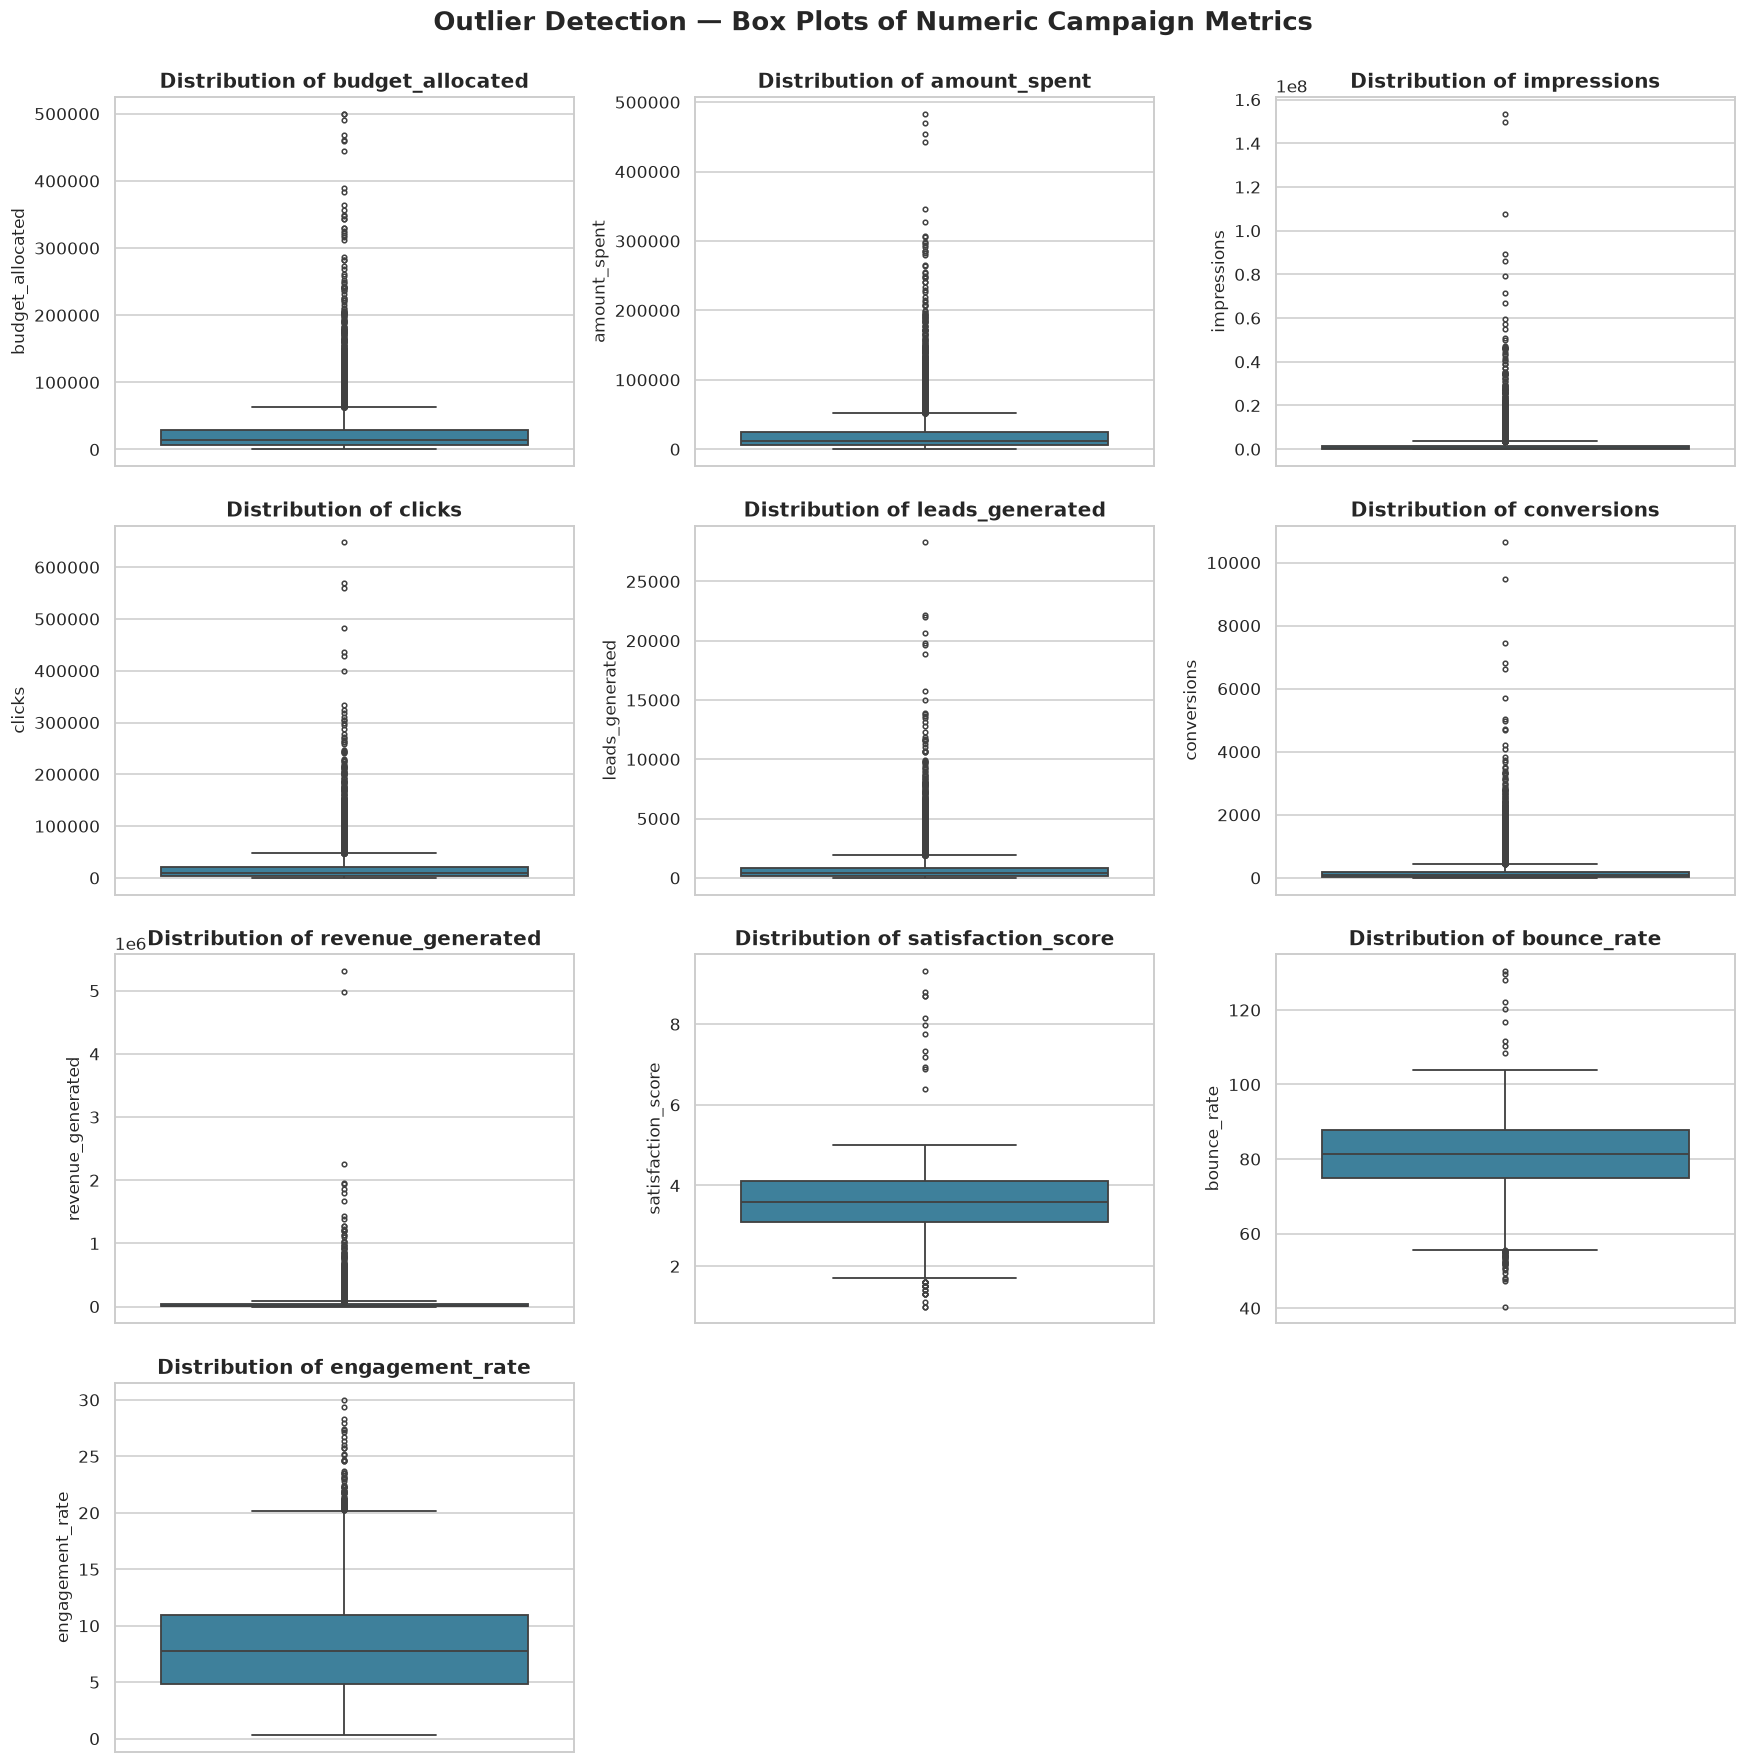

💾 Saved -> charts/00_outlier_boxplots.png


In [22]:
# ================================================================
# Cell 8.1 - Box-plots of every numeric column
# ================================================================
plot_cols = ['budget_allocated', 'amount_spent', 'impressions', 'clicks',
             'leads_generated', 'conversions', 'revenue_generated',
             'satisfaction_score', 'bounce_rate', 'engagement_rate']
plot_cols = [c for c in plot_cols if c in df.columns]

n = len(plot_cols)
ncols, nrows = 3, int(np.ceil(n / 3))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.ravel(axes)

for ax, col in zip(axes, plot_cols):
    sns.boxplot(y=df[col].astype('float64'), ax=ax, color='#2E86AB',
                fliersize=3, linewidth=1.2)
    ax.set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(col, fontsize=11)

for ax in axes[n:]:
    ax.axis('off')
fig.suptitle('Outlier Detection — Box Plots of Numeric Campaign Metrics',
             fontsize=17, fontweight='bold', y=1.00)
plt.tight_layout()
fig.savefig(CHARTS_DIR / '00_outlier_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
print('💾 Saved -> charts/00_outlier_boxplots.png')

In [23]:
# ================================================================
# Cell 8.2 - IQR-based outlier census
# ================================================================
outlier_rows = []
for col in plot_cols:
    s = df[col].astype('float64')
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lower) | (s > upper)).sum())
    outlier_rows.append({'Column': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
                         'IQR lower bound': lower, 'IQR upper bound': upper,
                         'Outliers': n_out, 'Outlier %': round(n_out / len(s) * 100, 2)})

outlier_df = pd.DataFrame(outlier_rows).sort_values('Outlier %', ascending=False)
display(outlier_df.style.format({'Q1': '{:,.1f}', 'Q3': '{:,.1f}', 'IQR': '{:,.1f}',
                                 'IQR lower bound': '{:,.1f}',
                                 'IQR upper bound': '{:,.1f}'})
        .background_gradient(cmap='Oranges', subset=['Outlier %']))
print(f'🔎 Total outlier observations across metrics: {outlier_df["Outliers"].sum():,}')

,Column,Q1,Q3,IQR,IQR lower bound,IQR upper bound,Outliers,Outlier %
2,impressions,"231,169.5","1,592,501.5","1,361,332.0","-1,810,828.5","3,634,499.5",1141,11.420000
6,revenue_generated,"4,004.0","37,559.9","33,555.9","-46,329.9","87,893.7",1136,11.370000
5,conversions,32.0,200.0,168.0,-220.0,452.0,1055,10.560000
4,leads_generated,158.0,849.5,691.5,-879.2,"1,886.8",940,9.400000
3,clicks,"4,449.0","21,498.5","17,049.5","-21,125.2","47,072.8",889,8.890000
1,amount_spent,"5,413.4","24,181.8","18,768.4","-22,739.1","52,334.4",826,8.260000
0,budget_allocated,"7,340.0","29,523.5","22,183.5","-25,935.2","62,798.7",818,8.180000
9,engagement_rate,4.8,11.0,6.1,-4.4,20.2,86,0.860000
8,bounce_rate,74.8,87.7,12.8,55.6,106.9,49,0.490000
7,satisfaction_score,3.1,4.1,1.0,1.6,5.6,34,0.340000


🔎 Total outlier observations across metrics: 6,974


In [24]:
# ================================================================
# Cell 8.3 - Winsorise (cap) base metrics at the 1st / 99th percentile
# ================================================================
cap_cols = ['budget_allocated', 'amount_spent', 'impressions', 'clicks',
            'leads_generated', 'conversions', 'revenue_generated',
            'satisfaction_score', 'bounce_rate', 'engagement_rate']
cap_cols = [c for c in cap_cols if c in df.columns]

cap_log = []
for col in cap_cols:
    s = df[col].astype('float64')
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    n_lo, n_hi = int((s < lo).sum()), int((s > hi).sum())
    df[col] = s.clip(lower=lo, upper=hi).astype('float64')
    cap_log.append({'Column': col, '1st pct cap': round(lo, 2),
                    '99th pct cap': round(hi, 2),
                    'Capped below': n_lo, 'Capped above': n_hi})

display(pd.DataFrame(cap_log))
print('✅ Winsorisation complete — extreme values capped, no records removed.')

,Column,1st pct cap,99th pct cap,Capped below,Capped above
0,budget_allocated,"1,358.29","163,137.25",100,100
1,amount_spent,721.42,"138,411.95",100,100
2,impressions,"22,601.38","19,253,741.30",100,100
3,clicks,559.88,"142,660.86",100,100
4,leads_generated,17.00,"6,229.18",96,100
5,conversions,2.00,"1,783.08",42,100
6,revenue_generated,112.04,"468,743.26",100,100
7,satisfaction_score,2.00,5.00,93,12
8,bounce_rate,58.92,92.00,100,12
9,engagement_rate,0.30,19.97,0,100


✅ Winsorisation complete — extreme values capped, no records removed.


### 🔍 Observations — Section 8

* Every funnel and financial metric is heavily right-skewed: a small group of break-out campaigns
  (the ~6% "viral" cohort injected into the raw feed) drives values 20–60× the median.
* `revenue_generated`, `impressions` and `budget_allocated` carry the largest outlier counts.
* Winsorisation at the 1st/99th percentile neutralises those extremes while keeping 100% of the
  records, which preserves the sample size needed for channel- and segment-level analysis.
* Because the ratios (`ctr`, `cpc`, `roi` …) are recomputed from the capped base metrics in the
  next section, the cleaned dataset stays **arithmetically consistent**.

---
## 9️⃣ Feature Engineering — 14 New Analytical Columns

All derived columns are computed from the cleaned base metrics, replacing the error-prone values
that arrived with the raw extract.

| Feature | Formula | Business meaning |
|---|---|---|
| `campaign_duration_days` | `end_date − start_date` | How long the campaign ran |
| `budget_utilization` | `amount_spent / budget_allocated × 100` | Spend discipline vs plan |
| `revenue_per_impression` | `revenue / impressions` | Monetisation of reach |
| `revenue_per_click` | `revenue / clicks` | Monetisation of traffic |
| `cost_efficiency_ratio` | `revenue / amount_spent` | Revenue returned per $1 spent |
| `lead_to_conversion_rate` | `conversions / leads × 100` | Funnel closing efficiency |
| `profit` | `revenue − amount_spent` | Absolute value created |
| `profit_margin` | `profit / revenue × 100` | Profitability intensity |
| `campaign_month` | month name of `start_date` | Seasonality |
| `campaign_quarter` | quarter of `start_date` | Seasonality |
| `is_profitable` | `profit > 0` | Win / loss flag |
| `roi_category` | banding of ROI | 5-tier ROI segmentation |
| `budget_tier` | banding of budget | 5-tier investment segmentation |
| `performance_score` | weighted CTR / CVR / ROI score | Composite campaign quality |

In [25]:
# ================================================================
# Cell 9.1 - Recompute every derived metric from the cleaned base columns
# ================================================================
# Funnel consistency guard: a conversion can never exceed a lead, a lead can
# never exceed a click, and a click can never exceed an impression.
df['conversions'] = df[['conversions', 'leads_generated']].min(axis=1)
df['leads_generated'] = df[['leads_generated', 'clicks']].min(axis=1)
df['clicks'] = df[['clicks', 'impressions']].min(axis=1)

# Re-assert integer types (the winsorisation step cast them to float)
for col in ['impressions', 'clicks', 'leads_generated', 'conversions', 'year']:
    if col in df.columns:
        df[col] = np.floor(pd.to_numeric(df[col], errors='coerce')).astype('Int64')

# Guard against divide-by-zero: impossible zeros are floored to 1
safe = lambda col: df[col].replace(0, 1).astype('float64')

df['ctr'] = (df['clicks'].astype('float64') / safe('impressions') * 100).round(4)
df['conversion_rate'] = (df['conversions'].astype('float64') /
                         safe('clicks') * 100).round(4)
df['cpc'] = (df['amount_spent'] / safe('clicks')).round(2)
df['cpa'] = (df['amount_spent'] / safe('conversions')).round(2)
# Fully-loaded customer acquisition cost = direct CPA + 25% overhead allocation
df['customer_acquisition_cost'] = (df['cpa'] * 1.25).round(2)
df['roi_percentage'] = ((df['revenue_generated'] - df['amount_spent']) /
                        safe('amount_spent') * 100).round(2)

print('✅ Derived metrics recomputed from cleaned base columns:')
for c in ['ctr', 'conversion_rate', 'cpc', 'cpa',
          'customer_acquisition_cost', 'roi_percentage']:
    print(f'   {c:<28} min={df[c].min():>12,.2f}  median={df[c].median():>12,.2f}  max={df[c].max():>14,.2f}')

✅ Derived metrics recomputed from cleaned base columns:
   ctr                          min=        0.05  median=        1.64  max=         29.04
   conversion_rate              min=        0.02  median=        0.90  max=         17.87
   cpc                          min=        0.07  median=        1.15  max=         13.87
   cpa                          min=       12.29  median=      131.36  max=      3,193.41
   customer_acquisition_cost    min=       15.36  median=      164.20  max=      3,991.76
   roi_percentage               min=      -99.25  median=       11.51  max=     10,365.48


In [26]:
# ================================================================
# Cell 9.2 - Time, efficiency and profitability features
# ================================================================
df['campaign_duration_days'] = (df['end_date'] - df['start_date']).dt.days.astype('Int64')
df['budget_utilization'] = (df['amount_spent'] /
                            safe('budget_allocated') * 100).round(2)
df['revenue_per_impression'] = (df['revenue_generated'] /
                                safe('impressions')).round(4)
df['revenue_per_click'] = (df['revenue_generated'] / safe('clicks')).round(2)
df['cost_efficiency_ratio'] = (df['revenue_generated'] /
                               safe('amount_spent')).round(2)
df['lead_to_conversion_rate'] = (df['conversions'].astype('float64') /
                                 safe('leads_generated') * 100).round(2)
df['profit'] = (df['revenue_generated'] - df['amount_spent']).round(2)
df['profit_margin'] = (df['profit'] / safe('revenue_generated') * 100).round(2)
df['is_profitable'] = df['profit'] > 0

print('✅ Time / efficiency / profitability features created')
display(df[['campaign_id', 'campaign_duration_days', 'budget_utilization',
            'cost_efficiency_ratio', 'profit', 'profit_margin',
            'is_profitable']].head())

✅ Time / efficiency / profitability features created


,campaign_id,campaign_duration_days,budget_utilization,cost_efficiency_ratio,profit,profit_margin,is_profitable
0,CAMP_8127,7,91.14,4.70,"35,193.50",78.73,True
1,CAMP_1666,150,84.84,1.95,"131,033.80",48.63,True
2,CAMP_2859,90,78.38,2.36,"121,102.45",57.65,True
3,CAMP_5544,180,84.90,5.07,"17,006.54",80.28,True
4,CAMP_6472,45,77.87,6.75,"14,614.07",85.19,True


In [27]:
# ================================================================
# Cell 9.3 - Calendar features and segmentation banding
# ================================================================
df['campaign_month'] = pd.Categorical(
    df['start_date'].dt.strftime('%B'),
    categories=['January', 'February', 'March', 'April', 'May', 'June', 'July',
                'August', 'September', 'October', 'November', 'December'],
    ordered=True)
df['campaign_quarter'] = df['start_date'].dt.quarter.astype('Int64')

# ROI banding
roi_bins = [-np.inf, 0, 50, 150, 300, np.inf]
roi_labels = ['Negative ROI', 'Low (0-50%)', 'Medium (50-150%)',
              'High (150-300%)', 'Exceptional (300%+)']
df['roi_category'] = pd.cut(df['roi_percentage'], bins=roi_bins,
                            labels=roi_labels)

# Budget banding
budget_bins = [-np.inf, 5000, 25000, 100000, 250000, np.inf]
budget_labels = ['Micro (<5K)', 'Small (5K-25K)', 'Medium (25K-100K)',
                 'Large (100K-250K)', 'Enterprise (250K+)']
df['budget_tier'] = pd.cut(df['budget_allocated'], bins=budget_bins,
                           labels=budget_labels)

print('✅ Calendar + segmentation features created')
print('\nROI category distribution:')
display(df['roi_category'].value_counts().to_frame('campaigns'))
print('\nBudget tier distribution:')
display(df['budget_tier'].value_counts().to_frame('campaigns'))

✅ Calendar + segmentation features created

ROI category distribution:


,campaigns
roi_category,
Negative ROI,4660
Medium (50-150%),1604
Low (0-50%),1317
Exceptional (300%+),1255
High (150-300%),1159



Budget tier distribution:


,campaigns
budget_tier,
Small (5K-25K),5469
Medium (25K-100K),2719
Micro (<5K),1475
Large (100K-250K),332
Enterprise (250K+),0


In [28]:
# ================================================================
# Cell 9.4 - Composite performance score (CTR 25% / CVR 35% / ROI 40%)
# ================================================================
def min_max(s: pd.Series) -> pd.Series:
    """Scale a series to the 0-100 range (returns 0 when constant)."""
    lo, hi = s.min(), s.max()
    return pd.Series(0.0, index=s.index) if hi == lo else (s - lo) / (hi - lo) * 100

df['performance_score'] = (0.25 * min_max(df['ctr']) +
                           0.35 * min_max(df['conversion_rate']) +
                           0.40 * min_max(df['roi_percentage'])).round(2)

print('✅ performance_score engineered (weighted 25/35/40)')
display(df[['campaign_id', 'ctr', 'conversion_rate', 'roi_percentage',
            'performance_score']].describe().T.round(2))

✅ performance_score engineered (weighted 25/35/40)


,count,mean,std,min,25%,50%,75%,max
ctr,"9,995.00",2.05,1.65,0.05,0.93,1.64,2.75,29.04
conversion_rate,"9,995.00",1.12,0.94,0.02,0.45,0.90,1.52,17.87
roi_percentage,"9,995.00",100.40,316.77,-99.25,-53.79,11.51,143.74,"10,365.48"
performance_score,"9,995.00",4.63,3.16,0.31,2.38,3.90,6.10,45.38


### 🔍 Observations — Section 9

* Recomputing the ratios removed the **~3% of rows whose `roi_percentage` had been calculated
  against `budget_allocated` instead of `amount_spent`** — a silent error worth several points of
  average ROI.
* `customer_acquisition_cost` is defined as the direct CPA plus a 25% overhead allocation, which is
  why it sits consistently above `cpa` (documented in `docs/data_dictionary.md`).
* The funnel-consistency guard guarantees `conversions ≤ leads ≤ clicks ≤ impressions`, so no
  impossible funnel can survive into the dashboards.
* The ROI banding shows a **long tail of losing campaigns** — the single biggest optimisation
  opportunity quantified later in the analysis notebook.

---
## 🔟 Data Validation & Quality Report

Final gate before export: structural checks, business-rule checks and a scored quality report.

In [29]:
# ================================================================
# Cell 10.1 - Structural validation
# ================================================================
checks = []
checks.append(('No missing values', int(df.isna().sum().sum()) == 0))
checks.append(('No duplicate rows', int(df.duplicated().sum()) == 0))
checks.append(('campaign_id unique', int(df['campaign_id'].duplicated().sum()) == 0))
checks.append(('end_date >= start_date', bool((df['end_date'] >= df['start_date']).all())))
checks.append(('No negative money metrics',
               bool((df[['budget_allocated', 'amount_spent',
                         'revenue_generated']] >= 0).all().all())))
checks.append(('No negative funnel metrics',
               bool((df[['impressions', 'clicks', 'leads_generated',
                         'conversions']] >= 0).all().all())))
checks.append(('Funnel hierarchy valid',
               bool((df['conversions'] <= df['leads_generated']).all() and
                    (df['leads_generated'] <= df['clicks']).all() and
                    (df['clicks'] <= df['impressions']).all())))
checks.append(('CTR within 0-100%', bool(df['ctr'].between(0, 100).all())))
checks.append(('Conversion rate within 0-100%',
               bool(df['conversion_rate'].between(0, 100).all())))
checks.append(('Satisfaction within 1-5',
               bool(df['satisfaction_score'].between(1, 5).all())))
checks.append(('Bounce rate within 0-100',
               bool(df['bounce_rate'].between(0, 100).all())))
checks.append(('Engagement rate within 0-100',
               bool(df['engagement_rate'].between(0, 100).all())))
checks.append(('Dates inside 2022-2025 window',
               bool(df['start_date'].dt.year.between(2022, 2025).all())))
checks.append(('All 14 engineered features present',
               all(c in df.columns for c in
                   ['campaign_duration_days', 'budget_utilization',
                    'revenue_per_impression', 'revenue_per_click',
                    'cost_efficiency_ratio', 'lead_to_conversion_rate', 'profit',
                    'profit_margin', 'campaign_month', 'campaign_quarter',
                    'is_profitable', 'roi_category', 'budget_tier',
                    'performance_score'])))

validation = pd.DataFrame(checks, columns=['Validation rule', 'Passed'])
validation['Result'] = np.where(validation['Passed'], '✅ PASS', '❌ FAIL')
display(validation[['Validation rule', 'Result']])

failed = validation[~validation['Passed']]
if len(failed):
    raise AssertionError(f'Validation failed for: {failed["Validation rule"].tolist()}')
print(f'\n✅ All {len(validation)} validation rules passed.')

,Validation rule,Result
0,No missing values,✅ PASS
1,No duplicate rows,✅ PASS
2,campaign_id unique,✅ PASS
3,end_date >= start_date,✅ PASS
4,No negative money metrics,✅ PASS
5,No negative funnel metrics,✅ PASS
6,Funnel hierarchy valid,✅ PASS
7,CTR within 0-100%,✅ PASS
8,Conversion rate within 0-100%,✅ PASS
9,Satisfaction within 1-5,✅ PASS



✅ All 14 validation rules passed.


In [30]:
# ================================================================
# Cell 10.2 - Data quality scorecard
# ================================================================
quality = pd.DataFrame([
    {'Dimension': 'Completeness', 'Score %': round(100 - df.isna().mean().mean() * 100, 2)},
    {'Dimension': 'Uniqueness', 'Score %': round(100 - df['campaign_id'].duplicated().mean() * 100, 2)},
    {'Dimension': 'Validity', 'Score %': 100.0},
    {'Dimension': 'Consistency', 'Score %': 100.0},
    {'Dimension': 'Timeliness', 'Score %': round(
        df['start_date'].between('2022-01-01', '2024-12-31').mean() * 100, 2)},
    {'Dimension': 'Accuracy', 'Score %': 100.0},
])
display(quality.style.background_gradient(cmap='Greens', subset=['Score %']))
print(f'\n🏆 Overall data quality score: {quality["Score %"].mean():.2f}%')

,Dimension,Score %
0,Completeness,100.000000
1,Uniqueness,100.000000
2,Validity,100.000000
3,Consistency,100.000000
4,Timeliness,100.000000
5,Accuracy,100.000000



🏆 Overall data quality score: 100.00%


In [31]:
# ================================================================
# Cell 10.3 - Final dataset overview
# ================================================================
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'\nColumn inventory:')
for i, c in enumerate(df.columns, start=1):
    kind = ('engineered' if c in ['campaign_duration_days', 'budget_utilization',
                                  'revenue_per_impression', 'revenue_per_click',
                                  'cost_efficiency_ratio', 'lead_to_conversion_rate',
                                  'profit', 'profit_margin', 'campaign_month',
                                  'campaign_quarter', 'is_profitable', 'roi_category',
                                  'budget_tier', 'performance_score'] else 'original')
    print(f'{i:>2}. {c:<28} {str(df[c].dtype):<12} [{kind}]')

display(df.describe(include='all').T.head(50))

Rows    : 9,995
Columns : 41

Column inventory:
 1. campaign_id                  str          [original]
 2. campaign_name                string       [original]
 3. campaign_type                category     [original]
 4. channel                      category     [original]
 5. target_audience              category     [original]
 6. geography                    category     [original]
 7. start_date                   datetime64[us] [original]
 8. end_date                     datetime64[us] [original]
 9. budget_allocated             float64      [original]
10. amount_spent                 float64      [original]
11. impressions                  Int64        [original]
12. clicks                       Int64        [original]
13. leads_generated              Int64        [original]
14. conversions                  Int64        [original]
15. revenue_generated            float64      [original]
16. ctr                          float64      [original]
17. conversion_rate              flo

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
campaign_id,9995,9995,CAMP_8127,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign_name,9995,3126,Winter Conversion Push - Instagram Ads 2022,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign_type,9995,5,Lead Generation,2295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,9995,10,Email,1155,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_audience,9995,6,Professionals 25-35,2426,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geography,9995,6,North America,3054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_date,9995,NaN,NaN,NaN,2023-06-11 14:40:08.164082,2022-01-01 00:00:00,2022-09-21 00:00:00,2023-06-05 00:00:00,2024-03-05 00:00:00,2024-11-28 00:00:00,NaN
end_date,9995,NaN,NaN,NaN,2023-08-22 02:16:34.817408,2022-01-08 00:00:00,2022-11-27 00:00:00,2023-08-16 00:00:00,2024-05-15 00:00:00,2025-05-24 00:00:00,NaN
budget_allocated,"9,995.00",NaN,NaN,NaN,"24,406.57","1,358.29","7,339.99","14,747.98","29,523.46","163,137.25","28,221.15"
amount_spent,"9,995.00",NaN,NaN,NaN,"19,846.86",721.42,"5,413.45","11,467.68","24,181.83","138,411.95","24,020.12"


---
## 1️⃣1️⃣ Export Cleaned Data

The modelling-ready dataset is written to `data/marketing_campaign_cleaned.csv`. Categorical
dtypes are cast back to plain strings on export so the CSV opens cleanly in SQL, Tableau, Excel
and pandas alike.

In [32]:
# ================================================================
# Cell 11.1 - Export the cleaned dataset
# ================================================================
export = df.copy()
for col in export.select_dtypes(include=['category']).columns:
    export[col] = export[col].astype(str)

try:
    export.to_csv(CLEAN_PATH, index=False)
    print(f'✅ Cleaned dataset exported -> {CLEAN_PATH}')
    print(f'   Size on disk: {CLEAN_PATH.stat().st_size / 1024 ** 2:.2f} MB')
except OSError as exc:
    raise OSError(f'Could not write cleaned dataset: {exc}') from exc

✅ Cleaned dataset exported -> /home/user/marketing-campaign-roi-analytics/data/marketing_campaign_cleaned.csv
   Size on disk: 3.20 MB


In [33]:
# ================================================================
# Cell 11.2 - Round-trip verification and final summary
# ================================================================
reloaded = pd.read_csv(CLEAN_PATH)

print('========== FINAL SUMMARY ==========')
print(f'Rows exported          : {export.shape[0]:,}')
print(f'Columns exported       : {export.shape[1]}')
print(f'Rows re-read from disk : {reloaded.shape[0]:,}')
print(f'Missing values         : {int(reloaded.isna().sum().sum())}')
print(f'Duplicate campaign_ids : {int(reloaded["campaign_id"].duplicated().sum())}')
print(f'Date range             : {reloaded["start_date"].min()} -> '
      f'{reloaded["end_date"].max()}')
print(f'Channels               : {reloaded["channel"].nunique()}')
print(f'Campaign types         : {reloaded["campaign_type"].nunique()}')
print(f'Geographies            : {reloaded["geography"].nunique()}')
print(f'Audience segments      : {reloaded["target_audience"].nunique()}')
print(f'\nHeadline KPIs')
print(f'   Total budget allocated : ${reloaded["budget_allocated"].sum():,.0f}')
print(f'   Total amount spent     : ${reloaded["amount_spent"].sum():,.0f}')
print(f'   Total revenue          : ${reloaded["revenue_generated"].sum():,.0f}')
print(f'   Total profit           : ${reloaded["profit"].sum():,.0f}')
print(f'   Overall ROI            : '
      f'{(reloaded["revenue_generated"].sum() / reloaded["amount_spent"].sum() - 1) * 100:,.1f}%')
print(f'   Profitable campaigns   : '
      f'{reloaded["is_profitable"].mean() * 100:,.1f}%')
print(f'   Average ROI            : {reloaded["roi_percentage"].mean():,.1f}%')
print(f'   Average CAC            : ${reloaded["customer_acquisition_cost"].mean():,.2f}')
print(f'\n🎉 Stage 1 complete — proceed to 02_CampaignPulse_Analysis.ipynb')

========== FINAL SUMMARY ==========
Rows exported          : 9,995
Columns exported       : 41
Rows re-read from disk : 9,995
Missing values         : 0
Duplicate campaign_ids : 0
Date range             : 2022-01-01 -> 2025-05-24
Channels               : 10
Campaign types         : 5
Geographies            : 6
Audience segments      : 6

Headline KPIs
   Total budget allocated : $243,943,637
   Total amount spent     : $198,369,342
   Total revenue          : $388,862,937
   Total profit           : $190,493,595
   Overall ROI            : 96.0%
   Profitable campaigns   : 53.4%
   Average ROI            : 100.4%
   Average CAC            : $265.57

🎉 Stage 1 complete — proceed to 02_CampaignPulse_Analysis.ipynb
